<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/w4_pytorch_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [28]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [29]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [30]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [31]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


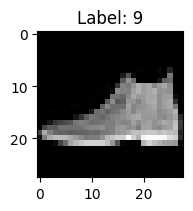

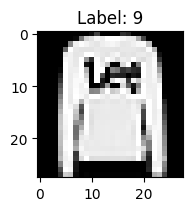

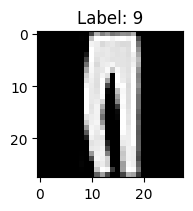

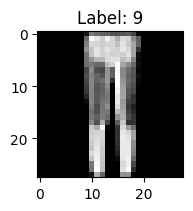

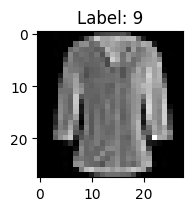

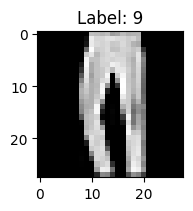

In [32]:
import matplotlib.pyplot as plt

# dataloader에서 첫 번째 배치만 가져옵니다.
examples = iter(test_dataloader)
images, labels = next(examples)

# 첫 번째 이미지의 채널 차원을 제거하고 출력 (1, 28, 28) -> (28, 28)

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[0].item()}")
    plt.show()

In [33]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [34]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [37]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [38]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [39]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.303682  [   64/60000]
loss: 2.295338  [ 6464/60000]
loss: 2.269571  [12864/60000]
loss: 2.272751  [19264/60000]
loss: 2.249680  [25664/60000]
loss: 2.210324  [32064/60000]
loss: 2.231692  [38464/60000]
loss: 2.183441  [44864/60000]
loss: 2.192911  [51264/60000]
loss: 2.156866  [57664/60000]
Test Error: 
 Accuracy: 28.0%, Avg loss: 2.154391 

Epoch 2
-------------------------------
loss: 2.164346  [   64/60000]
loss: 2.158490  [ 6464/60000]
loss: 2.097353  [12864/60000]
loss: 2.128090  [19264/60000]
loss: 2.068535  [25664/60000]
loss: 2.003131  [32064/60000]
loss: 2.038044  [38464/60000]
loss: 1.947215  [44864/60000]
loss: 1.966973  [51264/60000]
loss: 1.891050  [57664/60000]
Test Error: 
 Accuracy: 56.3%, Avg loss: 1.890341 

Epoch 3
-------------------------------
loss: 1.923159  [   64/60000]
loss: 1.892295  [ 6464/60000]
loss: 1.773508  [12864/60000]
loss: 1.832287  [19264/60000]
loss: 1.715140  [25664/60000]
loss: 1.662655  [32064/600

### 실전과제

- https://www.youtube.com/watch?v=ILsA4nyG7I0

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 장치 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# 1. 예제 데이터 및 Target 생성 (별첨 이미지 기준)
# [Batch, Features] 형태 -> [8, 4]
data_patterns = torch.tensor([
    # [0: solid] 패턴 2개
    [1.0, 1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0],

    # [1: vertical] 패턴 2개
    [0.0, 1.0, 0.0, 1.0], [1.0, 0.0, 1.0, 0.0],

    # [2: diagonal] 패턴 2개
    [1.0, 0.0, 0.0, 1.0], [0.0, 1.0, 1.0, 0.0],

    # [3: horizontal] 패턴 2개
    [1.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 1.0]
]).to(device)

# Target (각 패턴에 대한 정답 레이블) -> [8]
targets = torch.tensor([
    0, 0, # solid
    1, 1, # vertical
    2, 2, # diagonal
    3, 3  # horizontal
]).to(device)

print(f"Input Shape: {data_patterns.shape}, Target Shape: {targets.shape}")


# 2. FNN 네트워크 정의 (동일한 구조)
class PatternFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 4),
            nn.ReLU(),
            nn.Linear(4, 4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 4) # 최종 클래스 4개
        )

    def forward(self, x):
        return self.network(x)

# 모델 생성 및 장치 이동
model = PatternFNN().to(device)

# 3. 손실 함수와 최적화 도구 설정
criterion = nn.CrossEntropyLoss() # 분류 문제의 핵심!
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam이 수렴이 빠릅니다.

# 4. 학습 시작 (Epoch 루프)
epochs = 300 # 데이터를 여러 번 반복 학습
loss_history = []

print("\n학습 시작...")
for epoch in range(epochs):
    # (1) 예측 (Forward)
    outputs = model(data_patterns)

    # (2) 손실 계산 (오답 체크)
    loss = criterion(outputs, targets)

    # (3) 역전파 (Backpropagation)
    optimizer.zero_grad() # 이전 단계의 계산 기록 초기화
    loss.backward()       # 오답의 원인 계산

    # (4) 가중치 수정 (Step)
    optimizer.step()

    # 50회마다 로그 출력
    if (epoch + 1) % 50 == 0:
        loss_history.append(loss.item())
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("\n학습 완료!")


# 5. 결과 시각화 (Loss 그래프) (선택 사항)
# plt.plot(loss_history)
# plt.title("Loss History")
# plt.xlabel("Epochs (x50)")
# plt.ylabel("Loss")
# plt.show()


# 6. 최종 예측 확인
model.eval() # 평가 모드 전환
with torch.no_grad():
    final_outputs = model(data_patterns)
    # 가장 높은 점수(Logit)를 가진 인덱스 찾기
    predicted_classes = torch.argmax(final_outputs, dim=1)

# 결과 해석
classes = ['solid', 'vertical', 'diagonal', 'horizontal']
print("\n[최종 학습 결과 확인]")
for i in range(len(data_patterns)):
    # 데이터를 다시 2x2 그리드로 펼쳐서 출력
    pattern = data_patterns[i].cpu().view(2, 2).numpy()
    pred = classes[predicted_classes[i].item()]
    target = classes[targets[i].item()]

    print(f"데이터 {i+1}:\n{pattern}\n-> 예측: {pred}, 정답: {target}")
    if pred == target:
        print("   (정답!)")
    else:
        print("   (오답..)")

Using cpu device
Input Shape: torch.Size([8, 4]), Target Shape: torch.Size([8])

학습 시작...
Epoch [50/300], Loss: 1.1344
Epoch [100/300], Loss: 0.5970
Epoch [150/300], Loss: 0.2837
Epoch [200/300], Loss: 0.2237
Epoch [250/300], Loss: 0.1988
Epoch [300/300], Loss: 0.1876

학습 완료!

[최종 학습 결과 확인]
데이터 1:
[[1. 1.]
 [1. 1.]]
-> 예측: solid, 정답: solid
   (정답!)
데이터 2:
[[0. 0.]
 [0. 0.]]
-> 예측: solid, 정답: solid
   (정답!)
데이터 3:
[[0. 1.]
 [0. 1.]]
-> 예측: vertical, 정답: vertical
   (정답!)
데이터 4:
[[1. 0.]
 [1. 0.]]
-> 예측: vertical, 정답: vertical
   (정답!)
데이터 5:
[[1. 0.]
 [0. 1.]]
-> 예측: vertical, 정답: diagonal
   (오답..)
데이터 6:
[[0. 1.]
 [1. 0.]]
-> 예측: diagonal, 정답: diagonal
   (정답!)
데이터 7:
[[1. 1.]
 [0. 0.]]
-> 예측: horizontal, 정답: horizontal
   (정답!)
데이터 8:
[[0. 0.]
 [1. 1.]]
-> 예측: horizontal, 정답: horizontal
   (정답!)


In [14]:
model

PatternFNN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [15]:
from torchsummary import summary

# (모델, 입력 데이터의 크기)
# 우리의 경우 픽셀이 4개이므로 (4,) 라고 적습니다.
summary(model, input_size=(4,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 4]              20
              ReLU-2                    [-1, 4]               0
            Linear-3                    [-1, 4]              20
              ReLU-4                    [-1, 4]               0
            Linear-5                    [-1, 8]              40
              ReLU-6                    [-1, 8]               0
            Linear-7                    [-1, 4]              36
Total params: 116
Trainable params: 116
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
